In [1]:
!pip install opencv-python

In [2]:
!pip install opencv-python-headless


In [3]:
import cv2
print(cv2.__version__)

4.13.0


In [4]:
import cv2
import numpy as np
from PIL import Image
from google.colab.patches import cv2_imshow

def get_limits(color):
    c = np.uint8([[color]])
    hsv_color = cv2.cvtColor(c, cv2.COLOR_BGR2HSV)
    hue = hsv_color[0][0][0]
    lower_limit = np.array([hue - 10, 100, 100], dtype=np.uint8)
    upper_limit = np.array([hue + 10, 255, 255], dtype=np.uint8)
    return lower_limit, upper_limit

try:
    # This triggers the browser webcam
    filename = take_photo()

    # Read the saved image
    frame = cv2.imread(filename)
    yellow = [0, 255, 255]

    hsvImage = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    lowerLimit, upperLimit = get_limits(color=yellow)
    mask = cv2.inRange(hsvImage, lowerLimit, upperLimit)

    mask_ = Image.fromarray(mask)
    bbox = mask_.getbbox()

    if bbox is not None:
        x1, y1, x2, y2 = bbox
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 5)

    # In Colab, you MUST use cv2_imshow
    cv2_imshow(frame)

except Exception as err:
    print(str(err))

name 'take_photo' is not defined


Click 'Allow' if prompted. I will take one photo and detect yellow.


<IPython.core.display.Javascript object>

Yellow object detected!


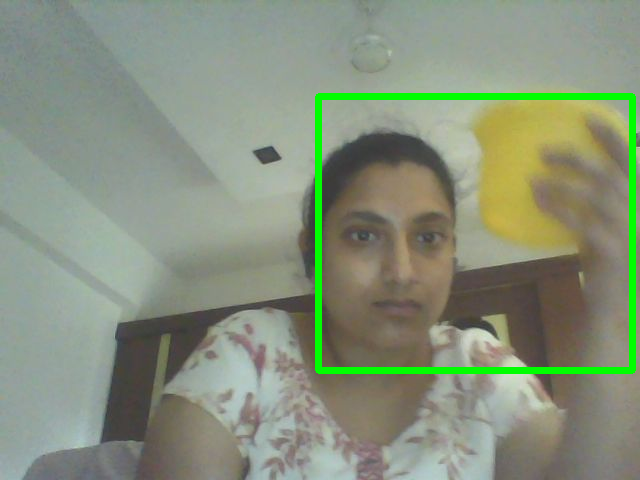

In [5]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import numpy as np
import cv2
from PIL import Image

# 1. JavaScript to handle the camera and return a frame
def capture_frame():
  js = Javascript('''
    async function getFrame() {
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      // Create a temporary canvas to grab the frame
      const canvas = document.createElement('canvas');
      const div = document.createElement('div');
      div.appendChild(video);
      document.body.appendChild(div);

      video.srcObject = stream;
      await video.play();

      // Wait a tiny bit for the camera to adjust to light
      await new Promise((resolve) => setTimeout(resolve, 100));

      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      // Stop the stream so the camera light turns off
      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', 0.8);
    }
  ''')
  display(js)
  return eval_js('getFrame()')

# 2. Utility for yellow detection
def get_limits(color):
    c = np.uint8([[color]])
    hsv_color = cv2.cvtColor(c, cv2.COLOR_BGR2HSV)
    hue = hsv_color[0][0][0]
    lower_limit = np.array([hue - 10, 100, 100], dtype=np.uint8)
    upper_limit = np.array([hue + 10, 255, 255], dtype=np.uint8)
    return lower_limit, upper_limit

# 3. Execution loop
from google.colab.patches import cv2_imshow

print("Click 'Allow' if prompted. I will take one photo and detect yellow.")

try:
    # Capture the image from JS
    data_url = capture_frame()

    # Decode base64 to OpenCV image
    header, encoded = data_url.split(",", 1)
    data = b64decode(encoded)
    np_data = np.frombuffer(data, dtype=np.uint8)
    frame = cv2.imdecode(np_data, cv2.IMREAD_COLOR)

    # DETECTION
    yellow = [0, 255, 255]
    hsvImage = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    lowerLimit, upperLimit = get_limits(color=yellow)
    mask = cv2.inRange(hsvImage, lowerLimit, upperLimit)

    mask_ = Image.fromarray(mask)
    bbox = mask_.getbbox()

    if bbox is not None:
        x1, y1, x2, y2 = bbox
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 5)
        print("Yellow object detected!")
    else:
        print("No yellow object found.")

    # Display result
    cv2_imshow(frame)

except Exception as e:
    print(f"Error: {e}")